In [33]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing,ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, root_mean_squared_error,mean_absolute_percentage_error, r2_score

In [34]:
df= joblib.load(r"dataset\df.pkl")

In [35]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,120.666667,10.263203,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,NaN,NaN


In [36]:
train= df.iloc[:-12,:]
test= df.iloc[-12:,:]

In [37]:
train.shape

(106, 10)

In [38]:
train= train.asfreq('MS')

In [39]:
test= test.asfreq('MS')

# Simple Exponential Smoothing (SES)

SES weights recent observations more heavily via a single smoothing parameter `alpha`, with no explicit trend or seasonal component. It's the baseline here — useful mainly to quantify how much trend/seasonal modeling actually buys us.

In [40]:
simple_model= SimpleExpSmoothing(train['#Passengers'].ffill()).fit()

In [41]:
simple_model.summary()

Dep. Variable:,#Passengers,No. Observations:,128
Model:,SimpleExpSmoothing,SSE,122413.001
Optimized:,True,AIC,882.480
Trend:,None,BIC,888.184
Seasonal:,None,AICC,882.805
Seasonal Periods:,None,Date:,"Wed, 12 Aug 2026"
Box-Cox:,False,Time:,17:45:25
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
initial_level,112.00000,l.0,False


In [42]:
simple_pred= simple_model.forecast(len(test))

In [43]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')

  values= {'mae': mae, 'mape': mape, 'r2': r2, 'rmse': rmse}
  value= pd.DataFrame(values, index=[0])
  return value
  

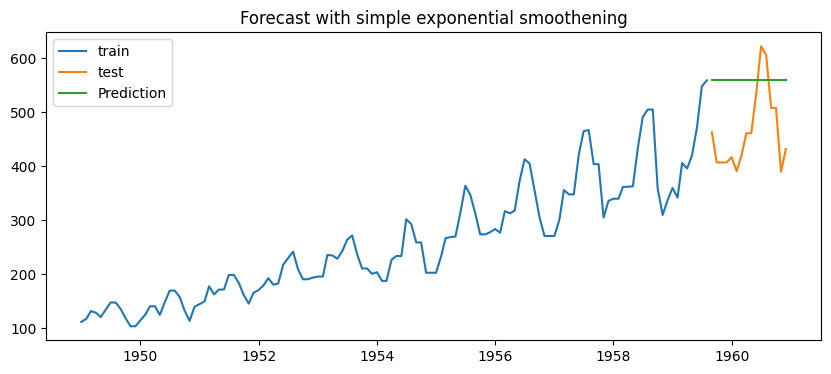

mean absolute error: 108.12
mean absolute percentage error: 25.0%
r2 score: -1.78
root mean squared error: 117.89


,mae,mape,r2,rmse
0,108.12,25.0,-1.78,117.89


In [44]:
model_evaluator(train['#Passengers'].ffill(),test['#Passengers'].ffill(),simple_pred, 'simple exponential smoothening')

# Double Exponential Smoothing (Holt's Linear Trend)

Adds an additive trend component (`trend='add'`) on top of SES. Still no seasonality, so we'd expect this to underperform on a series with the strong yearly cycle we saw in the decomposition — worth confirming against the metrics below rather than assuming.

In [45]:


double_smoothening= ExponentialSmoothing(train['#Passengers'].ffill(),
                                         seasonal=None,
                                         trend='mul',
                                         ).fit()

In [46]:
double_smoothening.summary()

Dep. Variable:,#Passengers,No. Observations:,128
Model:,ExponentialSmoothing,SSE,121599.978
Optimized:,True,AIC,885.627
Trend:,Multiplicative,BIC,897.035
Seasonal:,None,AICC,886.321
Seasonal Periods:,None,Date:,"Wed, 12 Aug 2026"
Box-Cox:,False,Time:,17:45:43
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,0.000000,beta,True


In [47]:
double_pred= double_smoothening.forecast(len(test))

In [48]:
double_pred

1959-09-01    564.120206
1959-10-01    569.287312
1959-11-01    574.501745
1959-12-01    579.763941
1960-01-01    585.074337
1960-02-01    590.433373
1960-03-01    595.841496
1960-04-01    601.299155
1960-05-01    606.806804
1960-06-01    612.364901
1960-07-01    617.973907
1960-08-01    623.634290
1960-09-01    629.346519
1960-10-01    635.111070
1960-11-01    640.928422
1960-12-01    646.799059
Freq: MS, dtype: float64

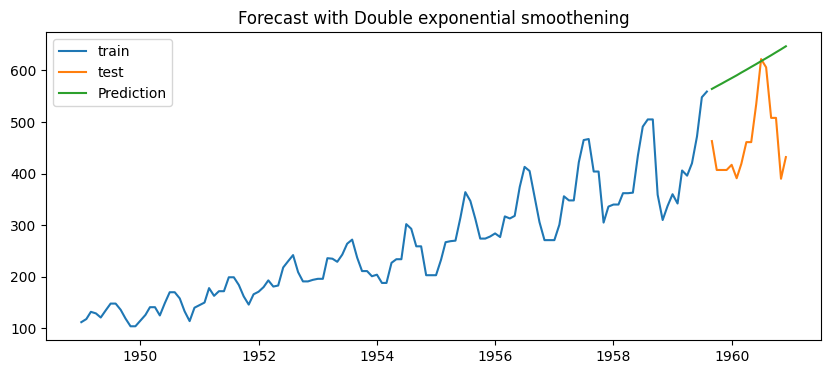

mean absolute error: 140.46
mean absolute percentage error: 33.0%
r2 score: -3.77
root mean squared error: 154.31


,mae,mape,r2,rmse
0,140.46,33.0,-3.77,154.31


In [49]:
model_evaluator(train['#Passengers'].ffill(),test['#Passengers'].ffill(),double_pred, 'Double exponential smoothening')

# Triple Exponential Smoothing (Holt-Winters)

Adds a seasonal component on top of trend. `trend='mul'` and `seasonal='mul'` are chosen (rather than `'add'`) because the seasonal decomposition earlier showed the amplitude of the seasonal swings **growing** as the passenger volume grows a multiplicative pattern. An additive model would assume a constant seasonal swing in absolute terms, which doesn't match what the data shows.

In [50]:
triple_smoothening= ExponentialSmoothing(train['#Passengers'].ffill(),
                                         seasonal='mul',
                                         trend='mul',
                                         seasonal_periods=12).fit()

In [51]:
triple_smoothening.summary()

Dep. Variable:,#Passengers,No. Observations:,128
Model:,ExponentialSmoothing,SSE,29617.093
Optimized:,True,AIC,728.842
Trend:,Multiplicative,BIC,774.474
Seasonal:,Multiplicative,AICC,735.117
Seasonal Periods:,12,Date:,"Wed, 12 Aug 2026"
Box-Cox:,False,Time:,17:45:51
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.4883635,alpha,True
smoothing_trend,0.000000,beta,True


In [52]:
triple_pred= triple_smoothening.forecast(len(test))

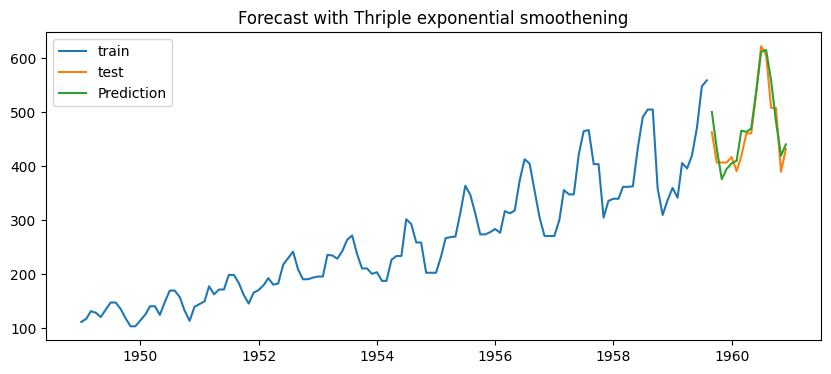

mean absolute error: 20.77
mean absolute percentage error: 5.0%
r2 score: 0.87
root mean squared error: 25.33


In [53]:
thriple_metrics=model_evaluator(train['#Passengers'].ffill(),test['#Passengers'].ffill(),triple_pred, 'Thriple exponential smoothening')

In [54]:
thriple_metrics.to_csv('dataset\\thriple_metric.csv')

In [55]:
test.isnull().sum()

#Passengers      4
month            4
quater           4
lag1             4
lag2             4
lag3             4
rolling_mean3    4
rolling_std3     4
rolling_mean6    4
rolling_std6     4
dtype: int64

In [56]:
train.isnull().sum()

#Passengers      22
month            22
quater           22
lag1             23
lag2             24
lag3             25
rolling_mean3    24
rolling_std3     24
rolling_mean6    27
rolling_std6     27
dtype: int64

In [57]:
df.isnull().sum()

#Passengers      0
month            0
quater           0
lag1             1
lag2             2
lag3             3
rolling_mean3    2
rolling_std3     2
rolling_mean6    5
rolling_std6     5
dtype: int64

In [58]:
df=df.asfreq('MS')

In [59]:
# Predicting the future

final_exponential_smoothening= ExponentialSmoothing(df['#Passengers'].ffill(),
                                                   seasonal='mul',
                                                  trend='mul',
                                                  seasonal_periods=12 ).fit()

In [60]:
final_exponential_smoothening.summary()

Dep. Variable:,#Passengers,No. Observations:,144
Model:,ExponentialSmoothing,SSE,39414.214
Optimized:,True,AIC,840.138
Trend:,Multiplicative,BIC,887.655
Seasonal:,Multiplicative,AICC,845.610
Seasonal Periods:,12,Date:,"Wed, 12 Aug 2026"
Box-Cox:,False,Time:,17:45:59
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.3047050,alpha,True
smoothing_trend,0.000000,beta,True


In [61]:
next_12_months= final_exponential_smoothening.forecast(12)

In [62]:
next_12_months

1961-01-01    443.332337
1961-02-01    441.066650
1961-03-01    495.323327
1961-04-01    503.223173
1961-05-01    508.716622
1961-06-01    585.231869
1961-07-01    667.576067
1961-08-01    666.741543
1961-09-01    587.384614
1961-10-01    525.595203
1961-11-01    455.761605
1961-12-01    479.822043
Freq: MS, dtype: float64

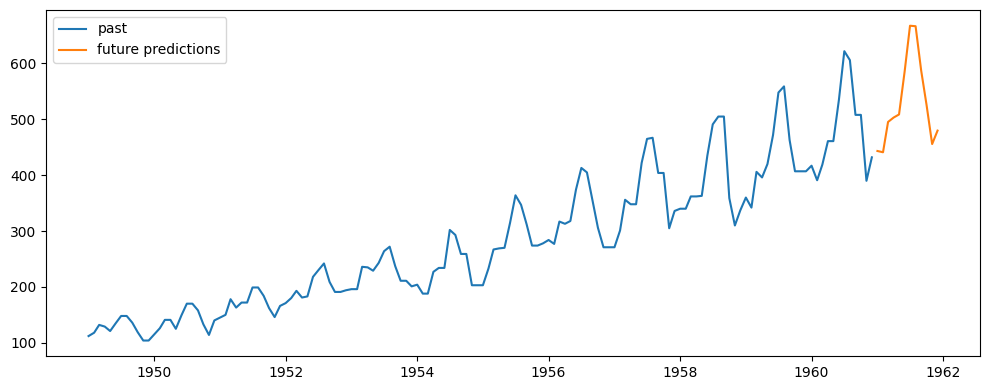

In [63]:
plt.figure(figsize=(10,4))

plt.plot(df['#Passengers'].ffill(), label= 'past')
plt.plot(next_12_months, label='future predictions')

plt.legend()
plt.tight_layout()
plt.show()

In [64]:
joblib.dump(final_exponential_smoothening, r"models\expo_smoothening.pkl" )

['models\\expo_smoothening.pkl']